### Reshaping `Reliance_5yr_data.csv` to Monthly OHCLV

In [ ]:
import pandas as pd

# Load the raw CSV file again to ensure we start from scratch with the new logic
raw_reliance_df = pd.read_csv('/content/Reliance_5yr_data.csv')

# Clean the DataFrame:
# 1. Skip the first two rows (metadata)
# 2. Rename the 'Price' column to 'Date'
cleaned_df_for_ohclv = raw_reliance_df.iloc[2:].copy()
cleaned_df_for_ohclv = cleaned_df_for_ohclv.rename(columns={'Price': 'Date'})

# Convert the 'Date' column to datetime and set as index
cleaned_df_for_ohclv['Date'] = pd.to_datetime(cleaned_df_for_ohclv['Date'], format='%Y-%m-%d')
cleaned_df_for_ohclv.set_index('Date', inplace=True)

# Convert OHLCV columns to numeric, coercing errors to NaN
ohclv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in ohclv_cols:
    cleaned_df_for_ohclv[col] = pd.to_numeric(cleaned_df_for_ohclv[col], errors='coerce')

# Define aggregation dictionary for monthly resampling
# 'ME' for month end frequency
monthly_ohclv_df = cleaned_df_for_ohclv.resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

# Display the first few rows of the new monthly OHCLV DataFrame
print("\nMonthly OHCLV Reliance Data:")
display(monthly_ohclv_df.head())


Monthly OHCLV Reliance Data:


,Open,High,Low,Close,Volume
Date,,,,,
2021-05-31,875.167680,993.785282,864.240034,979.547546,262158145
2021-06-30,982.132164,1035.106887,946.880034,960.371094,503558070
2021-07-31,963.715501,979.891108,917.417960,926.085999,215416700
2021-08-31,934.731237,1039.133718,928.747826,1027.485474,282080043
2021-09-30,1034.242361,1169.380960,1026.052128,1146.288940,328996430


In [ ]:
# Calculate the monthly return series from the 'Close' price of monthly_ohclv_df
# The first return will be NaN as there's no prior month to compare.
monthly_ohclv_return_series = monthly_ohclv_df['Close'].pct_change() * 100

print("\nMonthly OHCLV Return Series Head (Percentage Change):")
display(monthly_ohclv_return_series.head())


Monthly OHCLV Return Series Head (Percentage Change):


,Close
Date,
2021-05-31,NaN
2021-06-30,-1.957685
2021-07-31,-3.569984
2021-08-31,10.949250
2021-09-30,11.562545


In [ ]:
# Extract the 'Close' price as the monthly price series from the OHCLV data
monthly_ohclv_price_series = monthly_ohclv_df['Close']

print("\nMonthly OHCLV Price Series Head:")
display(monthly_ohclv_price_series.head())


Monthly OHCLV Price Series Head:


,Close
Date,
2021-05-31,979.547546
2021-06-30,960.371094
2021-07-31,926.085999
2021-08-31,1027.485474
2021-09-30,1146.288940


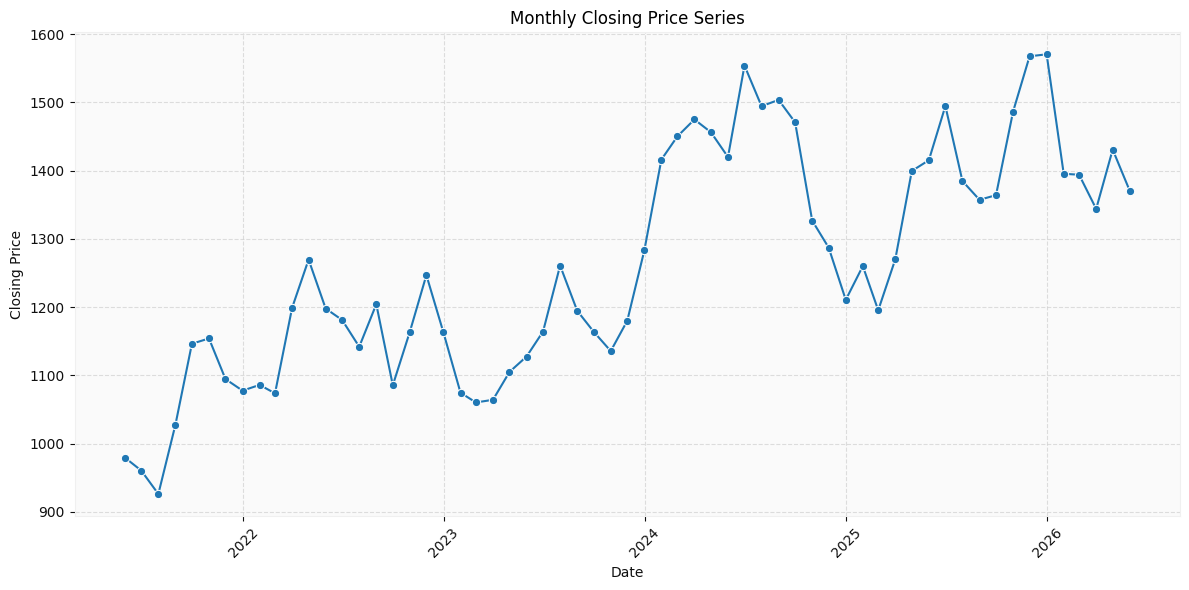

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb
plt.figure(figsize=(12, 6))
sb.lineplot(x=monthly_ohclv_df.index, y='Close', data=monthly_ohclv_df, marker='o', linestyle='-')
plt.title('Monthly Closing Price Series')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

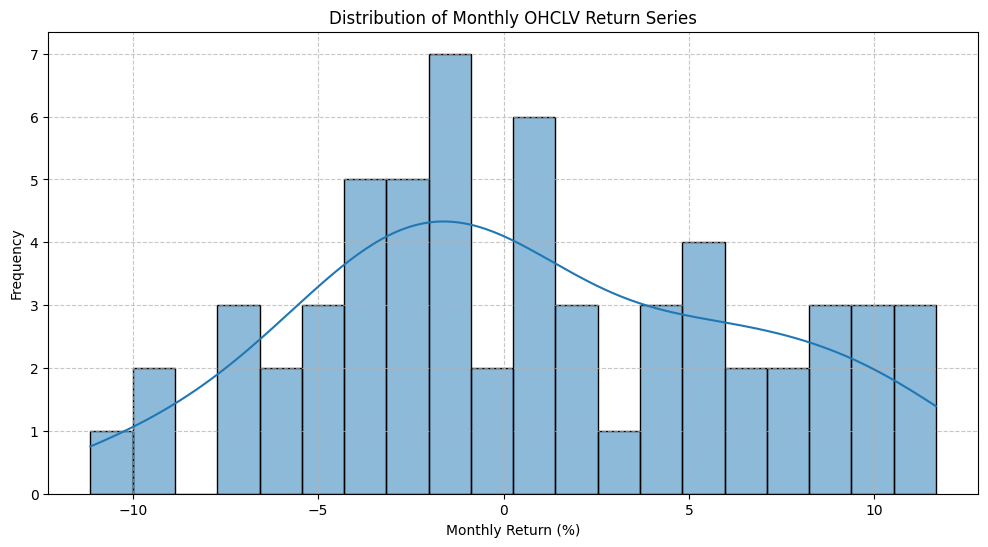

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(12, 6))
sb.histplot(monthly_ohclv_return_series, bins=20, kde=True)
plt.title('Distribution of Monthly OHCLV Return Series')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Install mplfinance if not already installed
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.2 MB/s eta 0:00:00


In [ ]:
import mplfinance as mpf
import matplotlib.pyplot as plt

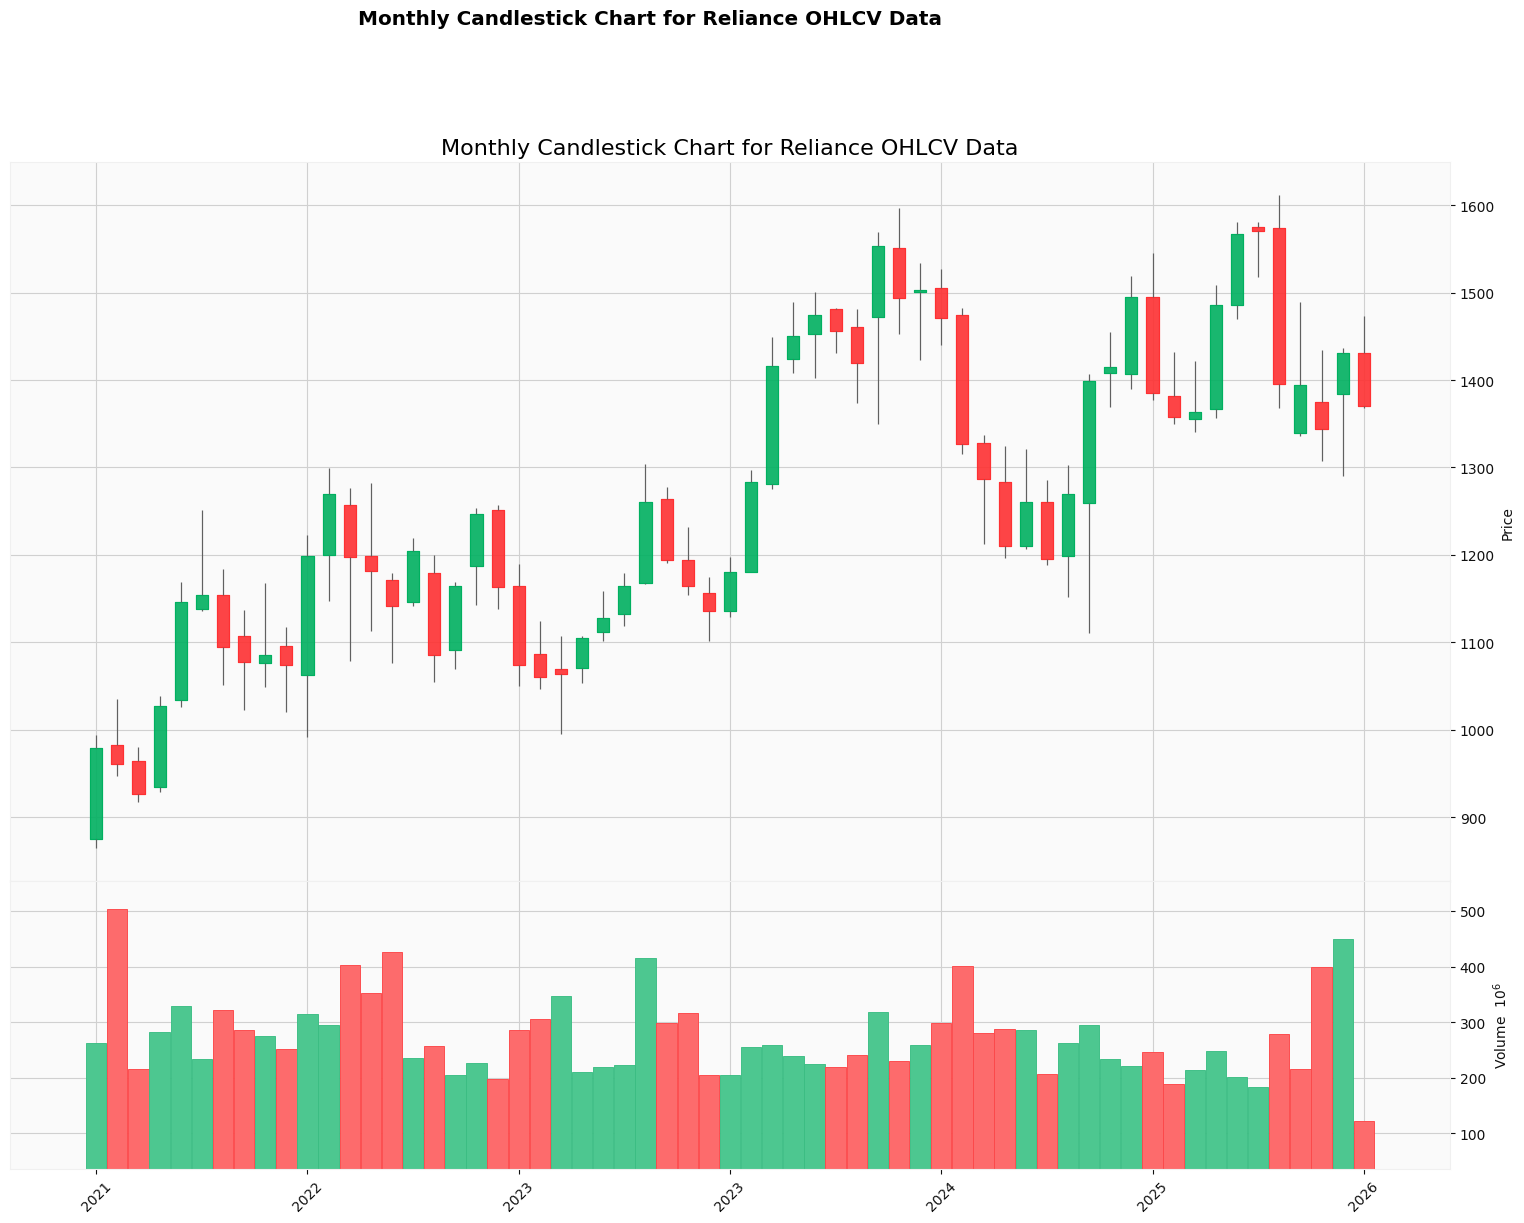

In [ ]:
import matplotlib.ticker as mticker

# Ensure the index is a DatetimeIndex for mplfinance
monthly_ohclv_df.index = pd.to_datetime(monthly_ohclv_df.index)

# Create the candlestick chart with the volume subplot
fig, axlist = mpf.plot(monthly_ohclv_df,
                       type='candle',
                       style='yahoo',
                       title='Monthly Candlestick Chart for Reliance OHLCV Data',
                       ylabel='Price',
                       # Removed ylabel_lower from here to prevent mplfinance from appending '10^6'
                       volume=True, # Set volume to True to include the volume subplot
                       returnfig=True,
                       figscale=2.5, # Increased figscale for better x-axis label visibility
                       datetime_format='%Y') # Display only the year on the x-axis

# Customize title for better readability
axlist[0].set_title('Monthly Candlestick Chart for Reliance OHLCV Data', fontsize=16)

# Get the volume axis (usually axlist[2] for candlestick charts with volume)
volume_ax = axlist[-1] # Assuming volume axis is the last one

# Define a formatter function for crores
def crores_formatter(x, pos):
    return f'{x / 10_000_000:.1f} Cr' # Divide by 1 Crore (10^7) and format with 1 decimal place

# Apply the formatter to the volume axis's y-ticks
volume_ax.yaxis.set_major_formatter(mticker.FuncFormatter(crores_formatter))

# Explicitly set the y-label for the volume axis after applying the formatter
volume_ax.set_ylabel('Volume (Crores)')

# Show the plot
plt.show()